# Part 2

## 1. Price Segmentation & Market Overview [7.5 Marks]
Divide the listings into three price tiers and analyse their distribution across boroughs. Provide a
high-level market summary for each price tier, incorporating property/room type, borough, and key
amenities to give a would-be host or guest a quick snapshot of the market.


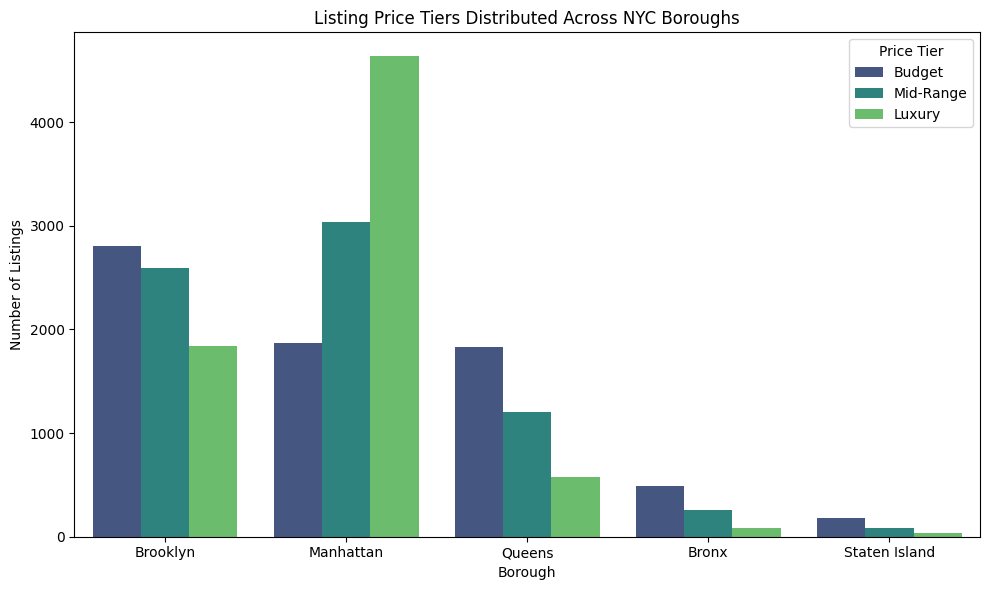

--- Market Snapshot by Price Tier ---

[Budget Tier]
Predominant Borough: Brooklyn
Predominant Room Type: Private room
Predominant Property Type: Private room in rental unit
Average Price: $77.48

[Mid-Range Tier]
Predominant Borough: Manhattan
Predominant Room Type: Entire home/apt
Predominant Property Type: Entire rental unit
Average Price: $178.17

[Luxury Tier]
Predominant Borough: Manhattan
Predominant Room Type: Entire home/apt
Predominant Property Type: Entire rental unit
Average Price: $579.04


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('listings.csv')

# 2. Clean the 'price' column (Vectorized)
# Strip '$' and ',' then convert to float
df['price_clean'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Drop rows where price is NaN for accurate segmentation
df_price = df.dropna(subset=['price_clean']).copy()

# 3. Price Segmentation into 3 tiers using quantiles (Vectorized)
# qcut divides the data into 3 equal-sized buckets
df_price['price_tier'] = pd.qcut(df_price['price_clean'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])

# 4. Analyse Distribution Across Boroughs
borough_tier_dist = pd.crosstab(df_price['neighbourhood_group_cleansed'], df_price['price_tier'])

# Visualizing the distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df_price, x='neighbourhood_group_cleansed', hue='price_tier', palette='viridis')
plt.title('Listing Price Tiers Distributed Across NYC Boroughs')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.legend(title='Price Tier')
plt.tight_layout()
plt.show()

# 5. High-Level Market Summary
print("--- Market Snapshot by Price Tier ---")
for tier in ['Budget', 'Mid-Range', 'Luxury']:
    print(f"\n[{tier} Tier]")
    
    # Filter data for the tier
    tier_data = df_price[df_price['price_tier'] == tier]
    
    # Top Borough
    top_borough = tier_data['neighbourhood_group_cleansed'].mode()[0]
    
    # Top Room Type
    top_room = tier_data['room_type'].mode()[0]
    
    # Top Property Type
    top_prop = tier_data['property_type'].mode()[0]
    
    print(f"Predominant Borough: {top_borough}")
    print(f"Predominant Room Type: {top_room}")
    print(f"Predominant Property Type: {top_prop}")
    print(f"Average Price: ${tier_data['price_clean'].mean():.2f}")

## 2. City-Level Comparative Analysis (Manhattan vs Brooklyn) [7.5 Marks]
Compare listing opportunities in Manhattan and Brooklyn by analysing differences in
room/property types, guest capacity (accommodates, as your size proxy), and prices. Highlight
both the residential segment and the small commercial/hotel-style segment (room_type == "Hotel
room") for a complete picture.


--- Listing Counts by Room Type ---
room_type                     Entire home/apt  Hotel room  Private room  \
neighbourhood_group_cleansed                                              
Brooklyn                                 3582          43          3520   
Manhattan                                6138         346          3004   

room_type                     Shared room  
neighbourhood_group_cleansed               
Brooklyn                               94  
Manhattan                              51  

--- Average Price and Capacity Metrics ---
  neighbourhood_group_cleansed        room_type  Average Price ($)  \
0                     Brooklyn  Entire home/apt         278.696156   
1                     Brooklyn       Hotel room         385.719302   
2                     Brooklyn     Private room         147.008506   
3                     Brooklyn      Shared room         118.961383   
4                    Manhattan  Entire home/apt         399.331900   
5                    Ma

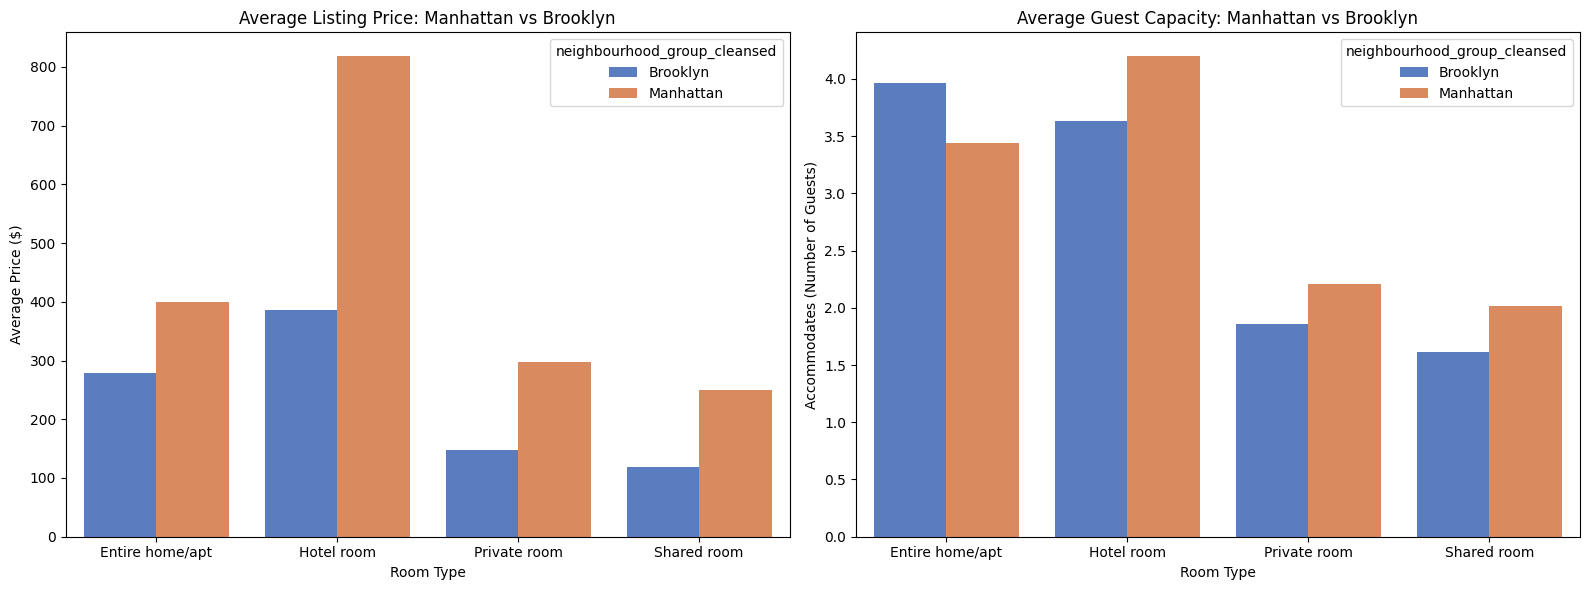

In [6]:
# 1. Filter data for Manhattan and Brooklyn
boroughs_of_interest = ['Manhattan', 'Brooklyn']
df_mb = df_price[df_price['neighbourhood_group_cleansed'].isin(boroughs_of_interest)].copy()

# 2. Analyze Room Types (Residential vs. Commercial/Hotel Segment)
room_type_counts = pd.crosstab(df_mb['neighbourhood_group_cleansed'], df_mb['room_type'])
print("--- Listing Counts by Room Type ---")
print(room_type_counts)

# 3. Calculate Average Price and Accommodates by Borough and Room Type
agg_metrics = df_mb.groupby(['neighbourhood_group_cleansed', 'room_type'])[['price_clean', 'accommodates']].mean().reset_index()
agg_metrics = agg_metrics.rename(columns={'price_clean': 'Average Price ($)', 'accommodates': 'Average Capacity (Guests)'})

print("\n--- Average Price and Capacity Metrics ---")
print(agg_metrics)

# 4. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Price Comparison
sns.barplot(
    data=agg_metrics, 
    x='room_type', 
    y='Average Price ($)', 
    hue='neighbourhood_group_cleansed', 
    ax=axes[0],
    palette='muted'
)
axes[0].set_title('Average Listing Price: Manhattan vs Brooklyn')
axes[0].set_ylabel('Average Price ($)')
axes[0].set_xlabel('Room Type')

# Plot 2: Average Guest Capacity (Accommodates) Comparison
sns.barplot(
    data=agg_metrics, 
    x='room_type', 
    y='Average Capacity (Guests)', 
    hue='neighbourhood_group_cleansed', 
    ax=axes[1],
    palette='muted'
)
axes[1].set_title('Average Guest Capacity: Manhattan vs Brooklyn')
axes[1].set_ylabel('Accommodates (Number of Guests)')
axes[1].set_xlabel('Room Type')

plt.tight_layout()
plt.show()

## 3. Location-Based Premium Analysis [5 Marks]
Within each borough, compare high-budget prime-location listings (define "prime" as
neighbourhoods whose median price sits in the top quartile of that borough) to similar
non-prime-location listings in terms of average guest capacity, amenity count, and price-per-guest.
Identify whether location justifies the price premium.


--- Prime vs. Non-Prime Averages by Borough ---
  neighbourhood_group_cleansed         is_prime  accommodates  amenity_count  \
0                        Bronx        Non-Prime      2.506192      32.147059   
1                        Bronx  Prime (Top 25%)      3.238889      33.522222   
2                     Brooklyn        Non-Prime      2.854844      32.002656   
3                     Brooklyn  Prime (Top 25%)      3.295590      33.097735   
4                    Manhattan        Non-Prime      2.925808      29.115241   
5                    Manhattan  Prime (Top 25%)      3.526203      30.575601   
6                       Queens        Non-Prime      2.707614      30.529611   
7                       Queens  Prime (Top 25%)      3.500000      31.692424   
8                Staten Island        Non-Prime      2.659004      35.191571   
9                Staten Island  Prime (Top 25%)      3.800000      34.342857   

   price_per_guest  
0        70.603231  
1        70.598622  
2       

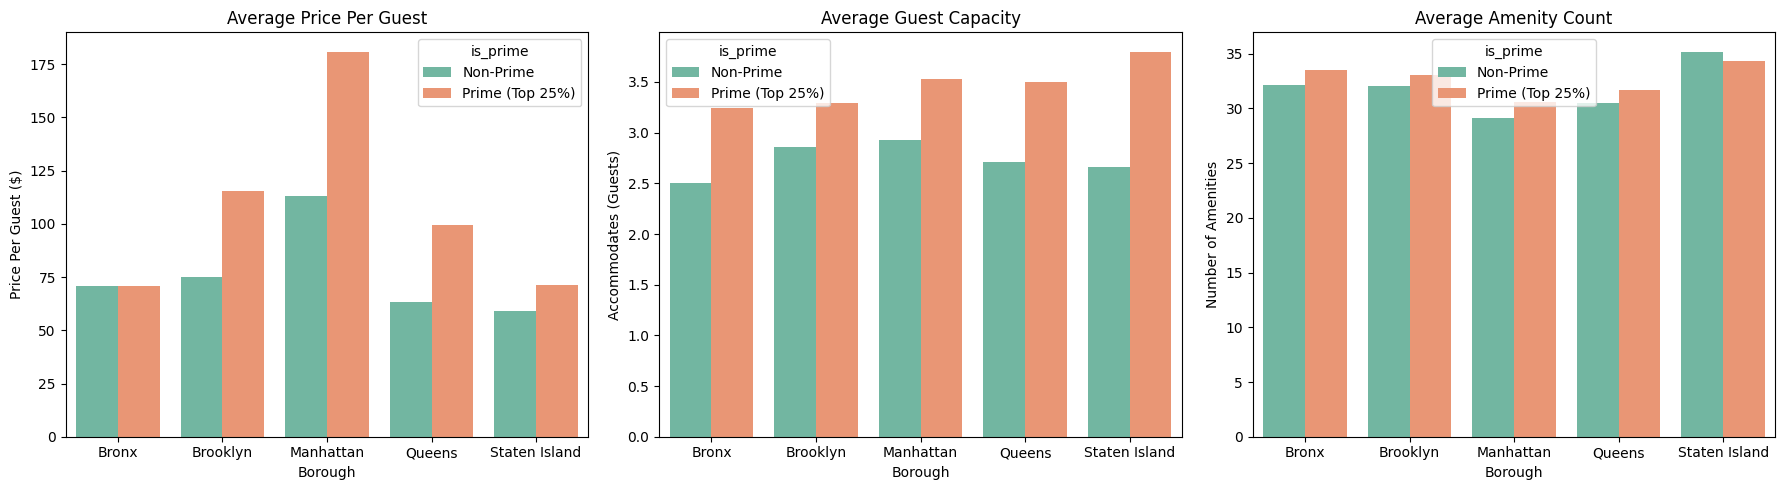

In [7]:
import ast

# (Assuming df_price is already created from Question 1)

# 1. Feature Engineering: Amenity Count & Price per Guest
def count_amenities(amenity_string):
    """Safely parses the amenity string and counts the items."""
    if pd.isna(amenity_string):
        return 0
    try:
        val = ast.literal_eval(amenity_string)
        return len(val) if isinstance(val, list) else 0
    except:
        return 0

# Apply the function to count amenities
df_price['amenity_count'] = df_price['amenities'].apply(count_amenities)

# Calculate price per guest (replace 0 accommodates with NaN to avoid division by zero)
df_price['price_per_guest'] = df_price['price_clean'] / df_price['accommodates'].replace(0, np.nan)


# 2. Define "Prime" Locations (Top Quartile Median Price per Borough)
# Step A: Calculate median price per neighborhood
neigh_median = df_price.groupby(['neighbourhood_group_cleansed', 'neighbourhood_cleansed'])['price_clean'].median().reset_index()
neigh_median.rename(columns={'price_clean': 'neigh_median_price'}, inplace=True)

# Step B: Find the 75th percentile (top quartile) for each borough
borough_q75 = neigh_median.groupby('neighbourhood_group_cleansed')['neigh_median_price'].transform(lambda x: x.quantile(0.75))

# Step C: Flag prime neighborhoods
neigh_median['is_prime'] = neigh_median['neigh_median_price'] >= borough_q75

# Step D: Merge the 'is_prime' flag back into our main dataset
df_price = df_price.merge(
    neigh_median[['neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'is_prime']], 
    on=['neighbourhood_group_cleansed', 'neighbourhood_cleansed'], 
    how='left'
)


# 3. Compare Prime vs. Non-Prime Listings
print("--- Prime vs. Non-Prime Averages by Borough ---")
premium_analysis = df_price.groupby(['neighbourhood_group_cleansed', 'is_prime'])[['accommodates', 'amenity_count', 'price_per_guest']].mean().reset_index()

# Make the boolean flag more readable
premium_analysis['is_prime'] = premium_analysis['is_prime'].map({True: 'Prime (Top 25%)', False: 'Non-Prime'})
print(premium_analysis)

# 4. Visualization: Price Premium Justification
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Price Per Guest
sns.barplot(data=premium_analysis, x='neighbourhood_group_cleansed', y='price_per_guest', hue='is_prime', ax=axes[0], palette='Set2')
axes[0].set_title('Average Price Per Guest')
axes[0].set_ylabel('Price Per Guest ($)')
axes[0].set_xlabel('Borough')

# Plot 2: Guest Capacity
sns.barplot(data=premium_analysis, x='neighbourhood_group_cleansed', y='accommodates', hue='is_prime', ax=axes[1], palette='Set2')
axes[1].set_title('Average Guest Capacity')
axes[1].set_ylabel('Accommodates (Guests)')
axes[1].set_xlabel('Borough')

# Plot 3: Amenity Count
sns.barplot(data=premium_analysis, x='neighbourhood_group_cleansed', y='amenity_count', hue='is_prime', ax=axes[2], palette='Set2')
axes[2].set_title('Average Amenity Count')
axes[2].set_ylabel('Number of Amenities')
axes[2].set_xlabel('Borough')

plt.tight_layout()
plt.show()

## 4. Value-for-Money Opportunities [10 Marks]
Identify listings offering the highest guest-capacity-per-dollar (accommodates / price) across all
boroughs. Present borough-wise rankings and insights into which segments deliver the best value for
budget-conscious guests

--- Borough-Wise Rankings (Median Capacity Per Dollar) ---
neighbourhood_group_cleansed  Median Capacity per Dollar
                       Bronx                    0.021227
               Staten Island                    0.020965
                      Queens                    0.018749
                    Brooklyn                    0.016000
                   Manhattan                    0.010979

--- Top 10 Best Value Segments (Borough & Room Type) ---
neighbourhood_group_cleansed       room_type  count  Median Capacity per Dollar
               Staten Island Entire home/apt    134                    0.025138
                       Bronx Entire home/apt    322                    0.023313
                   Manhattan     Shared room     51                    0.022563
                      Queens Entire home/apt   1361                    0.022009
                    Brooklyn     Shared room     94                    0.020513
                       Bronx    Private room    502          

/tmp/ipykernel_1761/3876717820.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


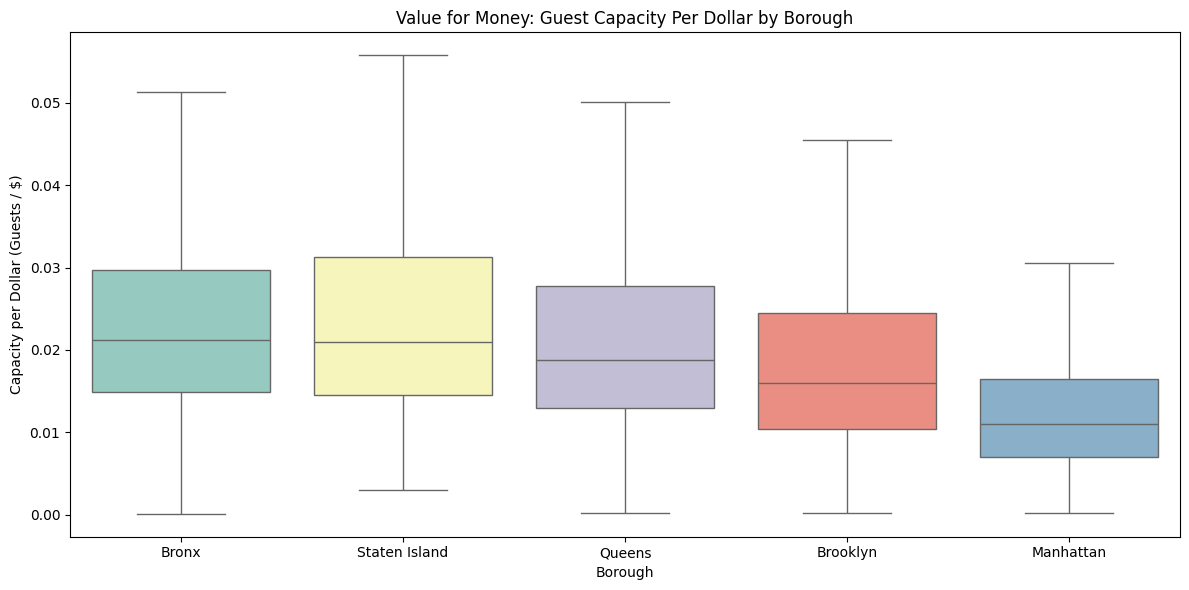


--- Top 5 Absolute Best Value Listings ---
                                                  name  \
9437                              Very good atmosphere   
254    *Available 1 year* 5BR Multi-Terrace Sunny Apt!   
15645                 Unfurnished 2BR UES 12 month MIN   
17257                 Luxury apartment-Three bedrooms.   
17254                    Sunny Duplex Skylights 2 bdrm   

      neighbourhood_group_cleansed        room_type  accommodates  \
9437                     Manhattan     Private room             2   
254                       Brooklyn  Entire home/apt            14   
15645                    Manhattan  Entire home/apt             4   
17257                       Queens  Entire home/apt             4   
17254                    Manhattan  Entire home/apt             6   

       price_clean  capacity_per_dollar  
9437          4.58             0.436681  
254          35.30             0.396601  
15645        10.45             0.382775  
17257        13.20      

In [8]:
# (Assuming df_price is already created from previous steps)

# 1. Calculate Guest-Capacity-Per-Dollar
# Filter out any zero prices to avoid division by zero errors
df_val = df_price[df_price['price_clean'] > 0].copy()

# Metric: Accommodates / Price
df_val['capacity_per_dollar'] = df_val['accommodates'] / df_val['price_clean']


# 2. Borough-Wise Rankings
print("--- Borough-Wise Rankings (Median Capacity Per Dollar) ---")
borough_value = df_val.groupby('neighbourhood_group_cleansed')['capacity_per_dollar'].median().reset_index()
borough_value = borough_value.sort_values(by='capacity_per_dollar', ascending=False)
borough_value = borough_value.rename(columns={'capacity_per_dollar': 'Median Capacity per Dollar'})
print(borough_value.to_string(index=False))


# 3. Segment Analysis (Borough + Room Type)
print("\n--- Top 10 Best Value Segments (Borough & Room Type) ---")
segment_value = df_val.groupby(['neighbourhood_group_cleansed', 'room_type'])['capacity_per_dollar'].agg(['count', 'median']).reset_index()
# Filter out segments with too few listings to be statistically relevant (e.g., less than 10 listings)
segment_value = segment_value[segment_value['count'] > 10]
segment_value = segment_value.sort_values(by='median', ascending=False)
segment_value = segment_value.rename(columns={'median': 'Median Capacity per Dollar'})
print(segment_value.head(10).to_string(index=False))


# 4. Visualization: Value Rankings
plt.figure(figsize=(12, 6))

# Boxplot to show the distribution of value across boroughs
sns.boxplot(
    data=df_val, 
    x='neighbourhood_group_cleansed', 
    y='capacity_per_dollar', 
    order=borough_value['neighbourhood_group_cleansed'],
    palette='Set3',
    showfliers=False # Hide extreme outliers for a cleaner view of the bulk of the data
)

plt.title('Value for Money: Guest Capacity Per Dollar by Borough')
plt.ylabel('Capacity per Dollar (Guests / $)')
plt.xlabel('Borough')
plt.tight_layout()
plt.show()

# 5. Spotlighting Top Value Listings
print("\n--- Top 5 Absolute Best Value Listings ---")
top_listings = df_val.sort_values(by='capacity_per_dollar', ascending=False).head(5)
print(top_listings[['name', 'neighbourhood_group_cleansed', 'room_type', 'accommodates', 'price_clean', 'capacity_per_dollar']])

## 5. Feature & Amenity Impact on Price [5 Marks]
Analyse how various amenities (e.g., Gym, Pool, Elevator, Hot tub, Pets allowed) and host reputation
(host_is_superhost) affect listing prices. Determine which features add the most value and whether
preferences differ across boroughs.


--- Price Premium ($) Added by Features & Amenities ---
(Positive numbers mean the feature adds value; negative means listings with the feature are cheaper on average)
Borough       Overall NYC   Bronx  Brooklyn  Manhattan  Queens  Staten Island
Feature                                                                      
Elevator           138.67  -49.40     16.41      92.38  -20.72         -62.69
Gym                285.04   43.26     72.36     269.36  298.76          93.13
Hot tub            101.18  107.64     56.42     154.78   13.66         239.72
Pets allowed       140.08   55.74     82.47     142.73   40.88          12.86
Pool               178.75  218.07    104.09     214.00   80.12          83.60
Superhost          -15.24  -29.93     18.54     -19.30  -14.03           8.00


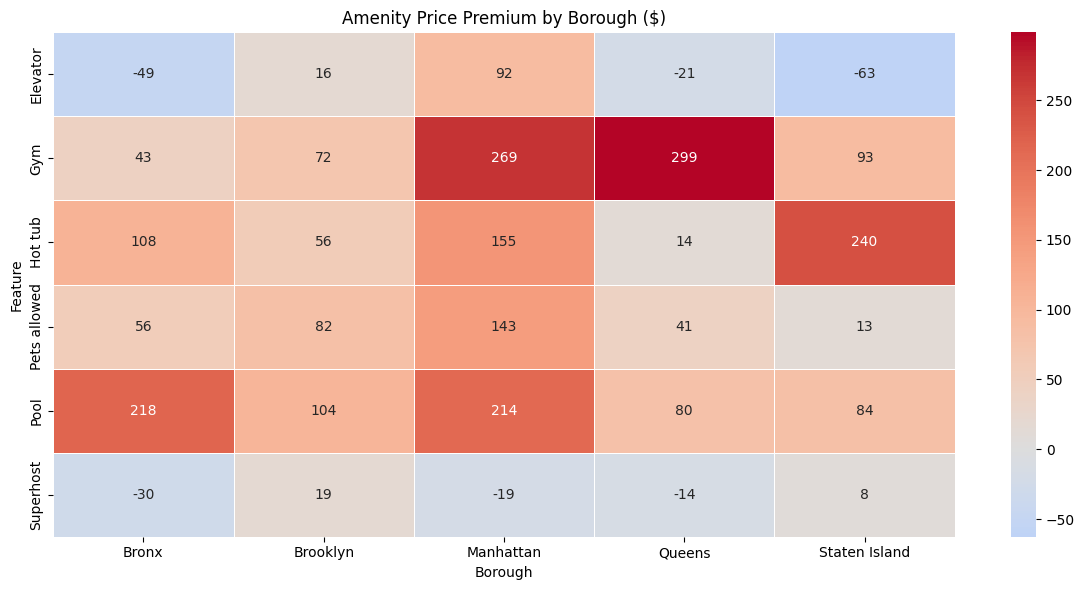

In [9]:
# 1. Feature Extraction using Vectorized String Matching
features_to_check = ['Gym', 'Pool', 'Elevator', 'Hot tub', 'Pets allowed']

for feat in features_to_check:
    # Create a boolean column for each feature. case=False ignores capitalization.
    col_name = f"has_{feat.lower().replace(' ', '_')}"
    df_price[col_name] = df_price['amenities'].str.contains(feat, case=False, na=False)

# 2. Host Reputation
df_price['is_superhost'] = df_price['host_is_superhost'] == 't'
# Add it to our list of features to analyze
features_to_check.append('Superhost')
df_price = df_price.rename(columns={'is_superhost': 'has_superhost'}) 


# 3. Calculate Price Premiums (Overall and Borough-Wise)
results = []
boroughs = df_price['neighbourhood_group_cleansed'].unique()

for feat in features_to_check:
    col_name = f"has_{feat.lower().replace(' ', '_')}"
    
    # Overall Impact
    avg_with = df_price[df_price[col_name]]['price_clean'].mean()
    avg_without = df_price[~df_price[col_name]]['price_clean'].mean()
    results.append({'Borough': 'Overall NYC', 'Feature': feat, 'Premium ($)': avg_with - avg_without})
    
    # Borough-Level Impact
    for borough in boroughs:
        b_df = df_price[df_price['neighbourhood_group_cleansed'] == borough]
        
        # We need a try-except here just in case a borough has 0 listings with a specific feature
        try:
            b_with = b_df[b_df[col_name]]['price_clean'].mean()
            b_without = b_df[~b_df[col_name]]['price_clean'].mean()
            premium = b_with - b_without
        except:
            premium = np.nan
            
        results.append({'Borough': borough, 'Feature': feat, 'Premium ($)': premium})

# 4. Format and Display the Data
premium_df = pd.DataFrame(results)
premium_pivot = premium_df.pivot(index='Feature', columns='Borough', values='Premium ($)')

# Reorder columns to put 'Overall NYC' first
cols = ['Overall NYC'] + [c for c in premium_pivot.columns if c != 'Overall NYC']
premium_pivot = premium_pivot[cols]

print("--- Price Premium ($) Added by Features & Amenities ---")
print("(Positive numbers mean the feature adds value; negative means listings with the feature are cheaper on average)")
print(premium_pivot.round(2))

# 5. Visualization: Heatmap of Feature Premiums
plt.figure(figsize=(12, 6))
# Exclude 'Overall NYC' from the heatmap to focus on geographic differences
sns.heatmap(
    premium_pivot.drop(columns=['Overall NYC']), 
    annot=True, 
    fmt=".0f", 
    cmap="coolwarm", 
    center=0,
    linewidths=.5
)
plt.title('Amenity Price Premium by Borough ($)')
plt.ylabel('Feature')
plt.xlabel('Borough')
plt.tight_layout()
plt.show()

## 6. Timeline & Readiness Effect on Pricing [10 Marks]
Investigate how booking readiness (derive from availability_30: fully booked / limited availability /
readily available) and listing maturity (years since first_review) influence prices in Manhattan and
Brooklyn. Highlight trends and takeaways for guests planning short-term vs long-term stays.

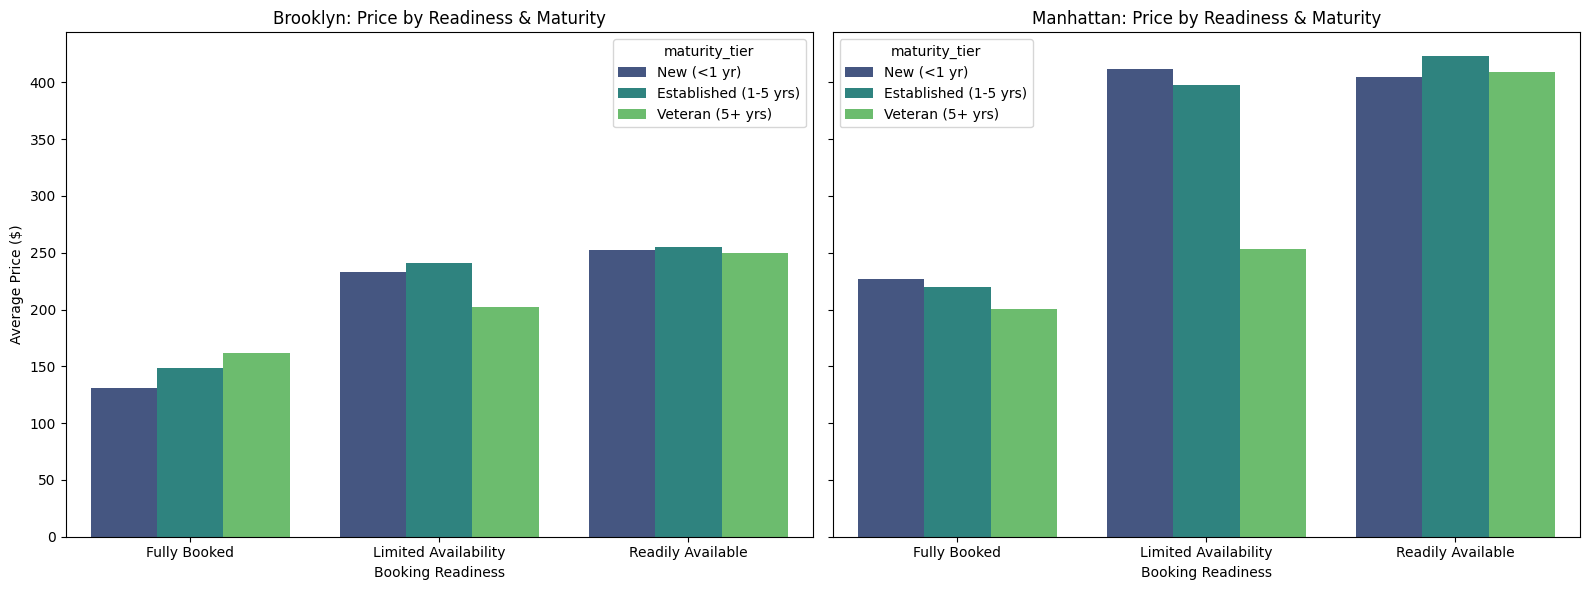

--- Average Price by Readiness and Maturity ---
readiness                                           Fully Booked  \
neighbourhood_group_cleansed maturity_tier                         
Brooklyn                     New (<1 yr)                  131.33   
                             Established (1-5 yrs)        148.55   
                             Veteran (5+ yrs)             161.58   
Manhattan                    New (<1 yr)                  226.90   
                             Established (1-5 yrs)        219.76   
                             Veteran (5+ yrs)             200.79   

readiness                                           Limited Availability  \
neighbourhood_group_cleansed maturity_tier                                 
Brooklyn                     New (<1 yr)                          233.11   
                             Established (1-5 yrs)                240.80   
                             Veteran (5+ yrs)                     202.30   
Manhattan                  

In [10]:
# 1. Filter for Manhattan and Brooklyn
df_mb = df_price[df_price['neighbourhood_group_cleansed'].isin(['Manhattan', 'Brooklyn'])].copy()

# 2. Derive Booking Readiness (Vectorized using pd.cut)
# Bins: [-1, 0, 15, 30] -> matches to (0), (1-15), (16-30)
df_mb['readiness'] = pd.cut(
    df_mb['availability_30'], 
    bins=[-1, 0, 15, 30], 
    labels=['Fully Booked', 'Limited Availability', 'Readily Available']
)

# 3. Derive Listing Maturity (Years since first_review)
# Convert string dates to datetime objects
df_mb['first_review_dt'] = pd.to_datetime(df_mb['first_review'])
df_mb['last_scraped_dt'] = pd.to_datetime(df_mb['last_scraped'])

# Calculate years difference
df_mb['maturity_years'] = (df_mb['last_scraped_dt'] - df_mb['first_review_dt']).dt.days / 365.25

# Group maturity into categories
df_mb['maturity_tier'] = pd.cut(
    df_mb['maturity_years'],
    bins=[0, 1, 5, 100], # 100 acts as an arbitrary high ceiling
    labels=['New (<1 yr)', 'Established (1-5 yrs)', 'Veteran (5+ yrs)']
)

# Drop rows where maturity is NaN (meaning they have never had a review)
df_timeline = df_mb.dropna(subset=['maturity_tier']).copy()


# 4. Aggregating the Data
timeline_analysis = df_timeline.groupby(['neighbourhood_group_cleansed', 'readiness', 'maturity_tier'], observed=False)['price_clean'].mean().reset_index()

# 5. Visualizing the Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for Brooklyn
sns.barplot(
    data=timeline_analysis[timeline_analysis['neighbourhood_group_cleansed'] == 'Brooklyn'],
    x='readiness',
    y='price_clean',
    hue='maturity_tier',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Brooklyn: Price by Readiness & Maturity')
axes[0].set_ylabel('Average Price ($)')
axes[0].set_xlabel('Booking Readiness')

# Plot for Manhattan
sns.barplot(
    data=timeline_analysis[timeline_analysis['neighbourhood_group_cleansed'] == 'Manhattan'],
    x='readiness',
    y='price_clean',
    hue='maturity_tier',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Manhattan: Price by Readiness & Maturity')
axes[1].set_xlabel('Booking Readiness')

plt.tight_layout()
plt.show()

# 6. Print a summary table for exact numbers
print("--- Average Price by Readiness and Maturity ---")
print(timeline_analysis.pivot_table(
    index=['neighbourhood_group_cleansed', 'maturity_tier'], 
    columns='readiness', 
    values='price_clean',
    observed=False
).round(2))

--- Average Price and Amenities by Host Portfolio Size ---
            portfolio_size  price_clean  amenity_count
0       Single Listing (1)       262.02          32.42
1    Small Portfolio (2-5)       252.04          31.89
2  Medium Portfolio (6-20)       306.10          29.20
3    Large Portfolio (21+)       317.12          27.79


/tmp/ipykernel_1761/1385055992.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1761/1385055992.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


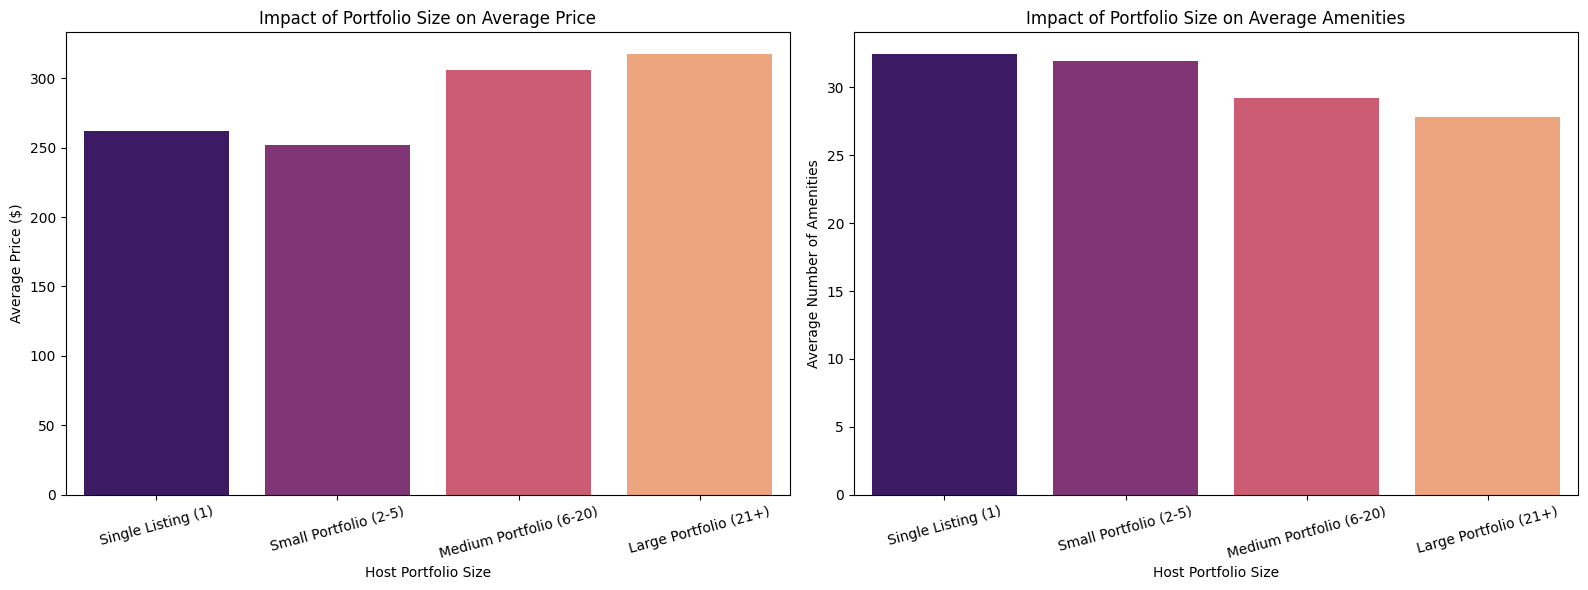

In [11]:
# 1. Feature Engineering: Amenity Count (if not already in your current dataframe state)
def count_amenities(amenity_string):
    if pd.isna(amenity_string):
        return 0
    try:
        val = ast.literal_eval(amenity_string)
        return len(val) if isinstance(val, list) else 0
    except:
        return 0

if 'amenity_count' not in df_price.columns:
    df_price['amenity_count'] = df_price['amenities'].apply(count_amenities)

# 2. Categorize Host Portfolio Size (Vectorized)
bins = [0, 1, 5, 20, np.inf]
labels = ['Single Listing (1)', 'Small Portfolio (2-5)', 'Medium Portfolio (6-20)', 'Large Portfolio (21+)']

df_price['portfolio_size'] = pd.cut(
    df_price['calculated_host_listings_count'], 
    bins=bins, 
    labels=labels
)

# 3. Analyze Impact on Price and Features
print("--- Average Price and Amenities by Host Portfolio Size ---")
host_analysis = df_price.groupby('portfolio_size', observed=False)[['price_clean', 'amenity_count']].mean().reset_index()
print(host_analysis.round(2))

# 4. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Price by Portfolio Size
sns.barplot(
    data=host_analysis, 
    x='portfolio_size', 
    y='price_clean', 
    palette='magma', 
    ax=axes[0]
)
axes[0].set_title('Impact of Portfolio Size on Average Price')
axes[0].set_ylabel('Average Price ($)')
axes[0].set_xlabel('Host Portfolio Size')
axes[0].tick_params(axis='x', rotation=15) # Rotate labels for better readability

# Plot 2: Average Amenity Count by Portfolio Size
sns.barplot(
    data=host_analysis, 
    x='portfolio_size', 
    y='amenity_count', 
    palette='magma', 
    ax=axes[1]
)
axes[1].set_title('Impact of Portfolio Size on Average Amenities')
axes[1].set_ylabel('Average Number of Amenities')
axes[1].set_xlabel('Host Portfolio Size')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()